In [19]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40663 instead
  warnings.warn(


In [ ]:
import os
foldername = '/home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/skill/'
os.makedirs(foldername, exist_ok=True)

In [30]:
import pandas as pd
import numpy as np

# ═══════════════════════════════════════════════════════════════════
#  FORECAST PARAMETERS — only change start_date to switch forecasts
# ═══════════════════════════════════════════════════════════════════
start_date = pd.Timestamp('2013-07-01')

# Data directories (auto-constructed from start_date; verify for 2012 runs)
month_str = start_date.strftime('%b').lower()   # e.g. 'jul'
day_str   = start_date.strftime('%d')            # e.g. '01'
year_str  = start_date.strftime('%Y')            # e.g. '2013'

# 2013: /data/SO3/averdy/TPOSE6/{month}{year}/diags_daily/
# 2012: /data/SO6/TPOSE_diags/tpose6/{month}{year}/diags/  ← verify suffix
noTAO_data_dir          = f'/data/SO3/averdy/TPOSE6/{month_str}{year_str}/diags_daily/'
noTAO_forecast_data_dir = f'/data/SO3/edavenport/tpose6/forecasts/{month_str}{day_str}{year_str}_tpose_noVel/'
vel_forecast_data_dir   = f'/data/SO3/edavenport/tpose6/forecasts/{month_str}{day_str}{year_str}/'

# ── Derived quantities (do not edit below) ───────────────────────
end_date        = start_date + pd.DateOffset(months=4) - pd.Timedelta(days=1)
n_forecast_days = (end_date - start_date).days   # e.g. 122 for Jul 1–Oct 31
n_eval          = n_forecast_days
eval_start_date = start_date

ref_date  = start_date.strftime('%Y-%m-%d')
itPerFile = 72
num_diags = n_forecast_days + 1

eval_slice = slice(0, n_forecast_days)
days       = np.arange(1, n_forecast_days + 1)   # day 1 = start_date

# Month boundary day numbers and label centers (for figure)
month_starts_in_window = pd.date_range(
    start_date + pd.offsets.MonthBegin(1), end_date, freq='MS'
)
month_bounds = {ms.strftime('%b 1'): (ms - start_date).days + 1
                for ms in month_starts_in_window}

all_month_starts = [start_date] + list(month_starts_in_window)
month_centers = []
for i, ms in enumerate(all_month_starts):
    me = all_month_starts[i + 1] if i + 1 < len(all_month_starts) else end_date + pd.Timedelta(days=1)
    center_day = (ms - start_date).days + (me - ms).days // 2 + 1
    month_centers.append((ms.strftime('%b'), center_day))

print(f'Forecast     : {start_date.date()} → {end_date.date()} ({n_forecast_days} days)')
print(f'noTAO est dir: {noTAO_data_dir}')
print(f'noTAO fct dir: {noTAO_forecast_data_dir}')
print(f'Vel fct dir  : {vel_forecast_data_dir}')

Forecast     : 2013-07-01 → 2013-10-31 (122 days)
noTAO est dir: /data/SO3/averdy/TPOSE6/jul2013/diags_daily/
noTAO fct dir: /data/SO3/edavenport/tpose6/forecasts/jul012013_tpose_noVel/
Vel fct dir  : /data/SO3/edavenport/tpose6/forecasts/jul012013/


### Load TPOSE Estimates and Forecasts

In [31]:
import matplotlib.pyplot as plt
import xarray as xr
from xmitgcm import open_mdsdataset
plt.rcParams['font.size'] = 14

prefix   = ['diag_state']
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'
intervals = range(itPerFile, itPerFile * num_diags, itPerFile)

def open_tpose(data_dir):
    ds = open_mdsdataset(
        data_dir=data_dir, grid_dir=grid_dir,
        iters=intervals, prefix=prefix, ref_date=ref_date, delta_t=1200)
    for coord in ['XC', 'YC', 'Z', 'XG', 'YG']:
        ds[coord] = ds[coord].astype(float)
    return ds

ds_tpose_noTAO          = open_tpose(noTAO_data_dir)
ds_tpose_noTAO_forecast = open_tpose(noTAO_forecast_data_dir)
ds_tpose_vel_forecast   = open_tpose(vel_forecast_data_dir)

### Load GLORYS Reanalysis

In [32]:
glorys = xr.open_mfdataset('/data/SO3/edavenport/tpose6/glorys_data/glorys_*.nc', combine='by_coords')

# Subset to evaluation window
glorys_wind = glorys[['uo', 'vo']].sel(
    time=slice(start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')),
    latitude=slice(-5, 5)
)

### Load and Daily-Average TAO ADCP Data

ADCP moorings used here are at the equator (lat=0) at 190°E (170°W), 220°E (140°W), and 250°E (110°W) —
the three sites that fall within the GLORYS domain. Hourly profiles are averaged to daily means. Fill value –9999 is masked as NaN.

In [33]:
adcp = xr.open_dataset('/data/SO3/edavenport/tpose6/tao_profiles/TAO_WO_2013_ADCP.nc')

# Parse dates
raw_dates = pd.to_datetime(
    adcp.prof_YYYYMMDD.values.astype(int).astype(str), format='%Y%m%d'
)

# Mask fill values
u_raw = adcp.prof_U.values.copy().astype(float)
v_raw = adcp.prof_V.values.copy().astype(float)
u_raw[u_raw == -9999.] = np.nan
v_raw[v_raw == -9999.] = np.nan

adcp_lons   = adcp.prof_lon.values     # per-profile longitudes
adcp_depths = adcp.prof_depth.values   # (62,) depth levels in meters

# Only the 3 equatorial ADCP sites within the GLORYS domain
tao_lons = np.array([190., 220., 250.])  # mooring longitudes (°E)

# Build daily-averaged arrays: (time, location, depth)
eval_dates = pd.date_range(start_date, periods=n_eval)
tao_u = np.full((n_eval, len(tao_lons), len(adcp_depths)), np.nan)
tao_v = np.full((n_eval, len(tao_lons), len(adcp_depths)), np.nan)

for i, d in enumerate(eval_dates):
    for j, lon in enumerate(tao_lons):
        mask = (raw_dates == d) & (adcp_lons == lon)
        if mask.sum() > 0:
            tao_u[i, j, :] = np.nanmean(u_raw[mask, :], axis=0)
            tao_v[i, j, :] = np.nanmean(v_raw[mask, :], axis=0)

print(f'TAO obs shape: {tao_u.shape}  (time, location, depth)')
print(f'Valid U obs (non-NaN): {np.sum(np.isfinite(tao_u))} / {tao_u.size}')
print(f'ADCP depth range: {adcp_depths[0]}–{adcp_depths[-1]} m')

TAO obs shape: (122, 3, 62)  (time, location, depth)
Valid U obs (non-NaN): 16931 / 22692
ADCP depth range: 10.0–315.0 m


/tmp/ipykernel_2748508/2399505786.py:29: RuntimeWarning: Mean of empty slice
  tao_u[i, j, :] = np.nanmean(u_raw[mask, :], axis=0)
/tmp/ipykernel_2748508/2399505786.py:30: RuntimeWarning: Mean of empty slice
  tao_v[i, j, :] = np.nanmean(v_raw[mask, :], axis=0)


### Interpolate Models to TAO Locations and Compute RMSE

TPOSE UVEL is on the XG (staggered-X) Arakawa-C grid; VVEL is on XC/YG.  
Both are interpolated to the ADCP mooring longitudes and depths (positive downward in metres).  
GLORYS uo/vo are on a regular –180:180 longitude grid; the TAO lons (190, 220, 250°E) are converted to –170, –140, –110 for interpolation.  

RMSE at each time step is the RMS across all valid (non-NaN) observation points (location × depth).

In [34]:
# Interpolation depths: match ADCP depth levels
interp_depths     = adcp_depths                # positive downward (m)
neg_interp_depths = -interp_depths             # TPOSE Z convention (negative)

# ── TPOSE extraction ─────────────────────────────────────────────────────────
def extract_tpose_vel(ds):
    """
    Interpolate UVEL and VVEL to TAO mooring locations and ADCP depths.
    Returns (u, v) each of shape (time, location, depth).

    xarray.interp preserves the original dim order, so after replacing
    Z→depth and XG/XC→location the result is (time, depth, location).
    Transpose to (time, location, depth) to match tao_u / tao_v.
    """
    ds = ds.isel(time=eval_slice)

    # Coordinate arrays for vectorised interp
    loc_da   = xr.DataArray(tao_lons,          dims='location')
    depth_da = xr.DataArray(neg_interp_depths, dims='depth')

    # UVEL: (time, Z, YC, XG) → sel YC → (time, Z, XG) → interp → (time, depth, location)
    u = (ds.UVEL
           .sel(YC=0.0, method='nearest')
           .interp(XG=loc_da, Z=depth_da, method='linear')
           .transpose('time', 'location', 'depth')
           .compute())

    # VVEL: (time, Z, YG, XC) → sel YG → (time, Z, XC) → interp → (time, depth, location)
    v = (ds.VVEL
           .sel(YG=0.0, method='nearest')
           .interp(XC=loc_da, Z=depth_da, method='linear')
           .transpose('time', 'location', 'depth')
           .compute())

    return u.values, v.values  # (time, location, depth)

print('Extracting TPOSE-noVel state estimate...')
noTAO_u,     noTAO_v     = extract_tpose_vel(ds_tpose_noTAO)
print('Extracting TPOSE-noVel forecast...')
noTAO_fct_u, noTAO_fct_v = extract_tpose_vel(ds_tpose_noTAO_forecast)
print('Extracting TPOSE-Vel forecast...')
vel_fct_u,   vel_fct_v   = extract_tpose_vel(ds_tpose_vel_forecast)
print('Done.')

# ── GLORYS extraction ─────────────────────────────────────────────────────────
# Convert TAO lons from 0–360 to –180:180 convention used by GLORYS
tao_lons_glorys = tao_lons - 360            # [190, 220, 250] → [–170, –140, –110]
loc_da_g   = xr.DataArray(tao_lons_glorys, dims='location')
depth_da_g = xr.DataArray(interp_depths,   dims='depth')  # GLORYS depth is positive

# GLORYS uo/vo: (time, depth, latitude, longitude) → sel lat → interp → (time, depth, location)
# transpose to (time, location, depth)
glorys_u = (glorys_wind.uo
              .sel(latitude=0.0, method='nearest')
              .interp(longitude=loc_da_g, depth=depth_da_g, method='linear')
              .transpose('time', 'location', 'depth')
              .isel(time=eval_slice)
              .compute()).values

glorys_v = (glorys_wind.vo
              .sel(latitude=0.0, method='nearest')
              .interp(longitude=loc_da_g, depth=depth_da_g, method='linear')
              .transpose('time', 'location', 'depth')
              .isel(time=eval_slice)
              .compute()).values

print('GLORYS extracted. Shape:', glorys_u.shape)

# ── RMSE functions ───────────────────────────────────────────────────────────
def point_rmse(model, obs):
    """RMS across valid obs points at each time step.
    model, obs: (time, location, depth)
    returns:    (time,)
    """
    diff = model - obs
    n_valid = np.sum(np.isfinite(diff), axis=(1, 2))
    return np.sqrt(np.nansum(diff**2, axis=(1, 2)) / n_valid)

def persistence_rmse(model_arr, obs_arr):
    """Use day-1 model field as constant forecast."""
    field = model_arr[0:1, :, :]
    return point_rmse(np.broadcast_to(field, model_arr.shape), obs_arr)

# ── Compute all RMSEs ─────────────────────────────────────────────────────────
rmse_noTAO_u          = point_rmse(noTAO_u,     tao_u)
rmse_noTAO_fct_u      = point_rmse(noTAO_fct_u, tao_u)
rmse_vel_fct_u        = point_rmse(vel_fct_u,   tao_u)
rmse_glorys_u         = point_rmse(glorys_u,    tao_u)
rmse_noTAO_fct_pers_u = persistence_rmse(noTAO_fct_u, tao_u)
rmse_vel_fct_pers_u   = persistence_rmse(vel_fct_u,   tao_u)

rmse_noTAO_v          = point_rmse(noTAO_v,     tao_v)
rmse_noTAO_fct_v      = point_rmse(noTAO_fct_v, tao_v)
rmse_vel_fct_v        = point_rmse(vel_fct_v,   tao_v)
rmse_glorys_v         = point_rmse(glorys_v,    tao_v)
rmse_noTAO_fct_pers_v = persistence_rmse(noTAO_fct_v, tao_v)
rmse_vel_fct_pers_v   = persistence_rmse(vel_fct_v,   tao_v)

Extracting TPOSE-noVel state estimate...
Extracting TPOSE-noVel forecast...
Extracting TPOSE-Vel forecast...
Done.
GLORYS extracted. Shape: (122, 3, 62)


### Figure: Velocity RMSE vs TAO ADCP

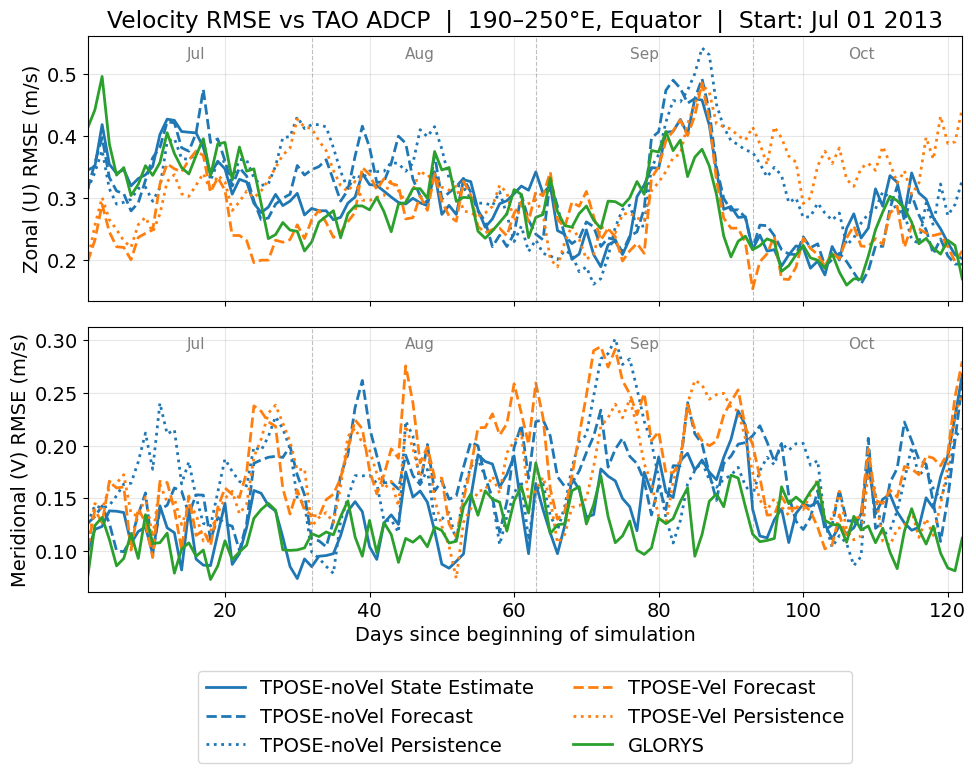

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for ax, (rmse_noTAO, rmse_noTAO_fct, rmse_noTAO_pers,
          rmse_vel_fct, rmse_vel_pers, rmse_glorys, label) in zip(
    axes,
    [
        (rmse_noTAO_u, rmse_noTAO_fct_u, rmse_noTAO_fct_pers_u,
         rmse_vel_fct_u, rmse_vel_fct_pers_u, rmse_glorys_u, 'Zonal (U)'),
        (rmse_noTAO_v, rmse_noTAO_fct_v, rmse_noTAO_fct_pers_v,
         rmse_vel_fct_v, rmse_vel_fct_pers_v, rmse_glorys_v, 'Meridional (V)'),
    ]
):
    # Line styles: solid = state estimate, dashed = forecast, dotted = persistence
    # Colors: C0 = TPOSE-noVel, C1 = TPOSE-Vel, C2 = GLORYS
    ax.plot(days, rmse_noTAO,      color='C0', lw=2, ls='-',  label='TPOSE-noVel State Estimate')
    ax.plot(days, rmse_noTAO_fct,  color='C0', lw=2, ls='--', label='TPOSE-noVel Forecast')
    ax.plot(days, rmse_noTAO_pers, color='C0', lw=2, ls=':',  label='TPOSE-noVel Persistence')
    ax.plot(days, rmse_vel_fct,    color='C1', lw=2, ls='--', label='TPOSE-Vel Forecast')
    ax.plot(days, rmse_vel_pers,   color='C1', lw=2, ls=':',  label='TPOSE-Vel Persistence')
    ax.plot(days, rmse_glorys,     color='C2', lw=2, ls='-',  label='GLORYS')

    for d in month_bounds.values():
        ax.axvline(d, color='gray', lw=0.8, linestyle='--', alpha=0.5)

    ymax = ax.get_ylim()[1]
    for mname, xpos in month_centers:
        ax.text(xpos, ymax * 0.97, mname, ha='center', va='top', color='gray', fontsize=11)

    ax.set_ylabel(f'{label} RMSE (m/s)')
    ax.set_xlim(days[0], days[-1])
    ax.grid(alpha=0.3)

axes[0].set_title(
    f'Velocity RMSE vs TAO ADCP  |  190–250°E, Equator  |  Start: {start_date.strftime("%b %d %Y")}'
)
axes[1].set_xlabel('Days since beginning of simulation')
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=2, borderaxespad=0)

plt.tight_layout()
plt.savefig(foldername + f'vel_rmse_vs_tao_{month_str}{day_str}{year_str}.png', dpi=150, bbox_inches='tight')
plt.show()

### Forecast Skill: Correlation vs TAO ADCP

Pearson correlation between each model's velocity profile and the TAO observations at each time step, computed across all valid (location × depth) points.

In [36]:
def profile_corr(model, obs):
    """Pearson r between model and obs at each time step.
    Flattens (location, depth) at each t and uses only points
    where both model and obs are finite.
    model, obs: (time, location, depth)
    returns:    (time,)
    """
    n_time = model.shape[0]
    r = np.full(n_time, np.nan)
    for t in range(n_time):
        m = model[t].ravel()
        o = obs[t].ravel()
        valid = np.isfinite(m) & np.isfinite(o)
        if valid.sum() > 1:
            r[t] = np.corrcoef(m[valid], o[valid])[0, 1]
    return r

def persistence_corr(model_arr, obs_arr):
    """Correlation using day-1 model field held constant."""
    field = np.broadcast_to(model_arr[0:1, :, :], model_arr.shape)
    return profile_corr(field, obs_arr)

# ── Zonal (U) ────────────────────────────────────────────────────────────────
corr_noTAO_u          = profile_corr(noTAO_u,     tao_u)
corr_noTAO_fct_u      = profile_corr(noTAO_fct_u, tao_u)
corr_vel_fct_u        = profile_corr(vel_fct_u,   tao_u)
corr_glorys_u         = profile_corr(glorys_u,    tao_u)
corr_noTAO_fct_pers_u = persistence_corr(noTAO_fct_u, tao_u)
corr_vel_fct_pers_u   = persistence_corr(vel_fct_u,   tao_u)

# ── Meridional (V) ───────────────────────────────────────────────────────────
corr_noTAO_v          = profile_corr(noTAO_v,     tao_v)
corr_noTAO_fct_v      = profile_corr(noTAO_fct_v, tao_v)
corr_vel_fct_v        = profile_corr(vel_fct_v,   tao_v)
corr_glorys_v         = profile_corr(glorys_v,    tao_v)
corr_noTAO_fct_pers_v = persistence_corr(noTAO_fct_v, tao_v)
corr_vel_fct_pers_v   = persistence_corr(vel_fct_v,   tao_v)

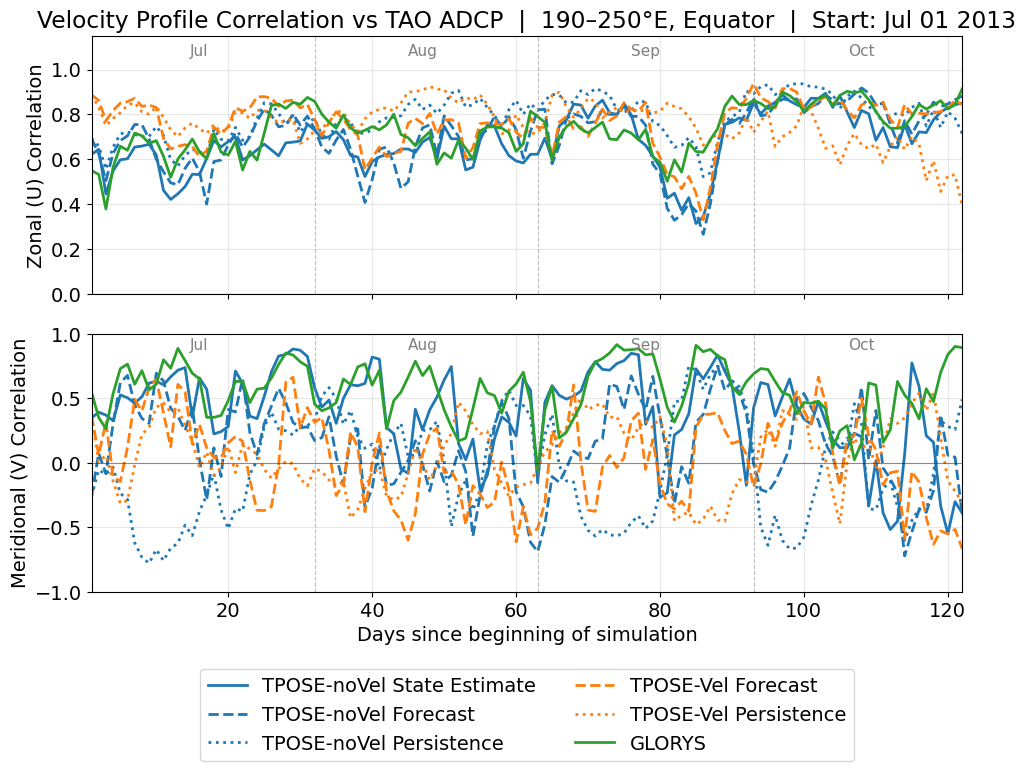

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ylims = [(0, 1.15), (-1, 1)]   # U: starts at 0, headroom above 1 for labels; V: full range

for ax, ylim, (corr_noTAO, corr_noTAO_fct, corr_noTAO_pers,
               corr_vel_fct, corr_vel_pers, corr_glorys, label) in zip(
    axes, ylims,
    [
        (corr_noTAO_u, corr_noTAO_fct_u, corr_noTAO_fct_pers_u,
         corr_vel_fct_u, corr_vel_fct_pers_u, corr_glorys_u, 'Zonal (U)'),
        (corr_noTAO_v, corr_noTAO_fct_v, corr_noTAO_fct_pers_v,
         corr_vel_fct_v, corr_vel_fct_pers_v, corr_glorys_v, 'Meridional (V)'),
    ]
):
    ax.plot(days, corr_noTAO,      color='C0', lw=2, ls='-',  label='TPOSE-noVel State Estimate')
    ax.plot(days, corr_noTAO_fct,  color='C0', lw=2, ls='--', label='TPOSE-noVel Forecast')
    ax.plot(days, corr_noTAO_pers, color='C0', lw=2, ls=':',  label='TPOSE-noVel Persistence')
    ax.plot(days, corr_vel_fct,    color='C1', lw=2, ls='--', label='TPOSE-Vel Forecast')
    ax.plot(days, corr_vel_pers,   color='C1', lw=2, ls=':',  label='TPOSE-Vel Persistence')
    ax.plot(days, corr_glorys,     color='C2', lw=2, ls='-',  label='GLORYS')

    ax.axhline(0, color='k', lw=0.8, ls='-', alpha=0.4)

    for d in month_bounds.values():
        ax.axvline(d, color='gray', lw=0.8, linestyle='--', alpha=0.5)

    for mname, xpos in month_centers:
        ax.text(xpos, ylim[1] * 0.97, mname, ha='center', va='top', color='gray', fontsize=11)

    ax.set_ylabel(f'{label} Correlation')
    ax.set_xlim(days[0], days[-1])
    ax.set_ylim(ylim)
    ax.grid(alpha=0.3)

axes[0].set_title(
    f'Velocity Profile Correlation vs TAO ADCP  |  190–250°E, Equator  |  Start: {start_date.strftime("%b %d %Y")}'
)
axes[1].set_xlabel('Days since beginning of simulation')
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=2, borderaxespad=0)

plt.tight_layout()
plt.savefig(foldername + f'vel_corr_vs_tao_{month_str}{day_str}{year_str}.png', dpi=150, bbox_inches='tight')
plt.show()